# PR15 · Connect QC decisions to time, coverage and study design

<!-- paper-first -->
### Begin with the paper question

**Read or revisit [PP02](../../curriculum/papers/processing.md#pp02), [PP01](../../curriculum/papers/processing.md#pp01).** Use the assigned first-pass sections in the guide; if you already read them, return only to the relevant figure or claim. Do this before the technical explanation below.

**Motivation:** How could the same censoring rule change both data quality and the people or time points represented?

Write a two-sentence prediction and one thing you cannot yet explain. Ask your AI tutor to locate evidence in the supplied paper and distinguish it from inference. A paper link motivates this question; it does not mean the paper uses every method demonstrated here.

**After the experiment:** revisit your prediction in the [evidence ledger](../../curriculum/coursework/EVIDENCE_LEDGER.md). Explain one mechanism you now understand, cite a result from this notebook, and name a paper claim this exercise still cannot test. Keep a small demonstration distinct from a reproduction of the study.
<!-- /paper-first -->

**Format:** 75–100 minutes for this lesson and its small executable lab, followed by the explicitly labeled upstream practice. Run this notebook from a fresh kernel, top to bottom. Core data are synthetic. Software: NumPy, SciPy, Matplotlib; extra imports are stated in code. This is one stage of a longer processing course, not a replacement for supervised research training.

## Learning objectives

- Compute transparent FD/DVARS-like summaries and state their conventions.
- Apply one censoring mask to all aligned arrays.
- Explain why QC thresholds require a study-level decision rule.

## Understand the operation

Quality control combines metadata, numerical summaries and visual evidence. No scalar certifies a dataset. Temporal standard deviation, mean signal, signal-to-noise summaries, motion measures and DVARS highlight different properties. DVARS measures frame-to-frame intensity change across included voxels, but its scale depends on how data were normalized and which variant is reported. High DVARS can coincide with movement, a scanner event or genuine widespread signal change; correlation with FD alone does not establish a cause.

Censoring marks observations that will not contribute in the ordinary way to a chosen analysis. Removing a frame must be coordinated across BOLD, confounds and design rows. The retained acquisition times still contain gaps. Joining them together as a new evenly sampled sequence silently changes time. Modeling spike regressors is another strategy with its own assumptions; these choices should be designed alongside filtering and statistical estimation rather than stacked arbitrarily.

The lab injects a single all-voxel intensity spike and one movement step into synthetic data. Difference-based summaries identify transitions on both sides of the event. A conservative illustrative rule masks high-change frames and reports retained counts and actual acquisition times. Its threshold is deliberately tied to the toy scale; it is not a recommended clinical or fMRI exclusion cutoff. In research, specify run/participant criteria before examining the target association, track how exclusion changes group composition and retained task events, and report unusable data honestly. Exclusion can itself introduce bias if it differs systematically across groups.

## Transformation contract

**Input:** time-by-voxel values, acquisition times, motion and design rows. **Output:** QC summaries and a shared retained-frame mask. **Preserved:** correspondence of retained rows and their original times. **Lost:** observations and possibly design information. **Never implied:** independence of neighboring retained frames.


## Read the actual course material

- [fMRIPrep: pipeline details](https://fmriprep.org/en/stable/workflows.html). Official project documentation; linked only.
- [fMRIPrep: public sample QC report](https://fmriprep.org/en/stable/_static/SampleReport/sample_report.html). Public report link; no image or participant data copied.

Read the named topic alongside this lesson; compare its real-image assumptions with our controlled example. These notebooks use original explanations and original code, not copied upstream passages. The source chapter is the place to continue to a complete real-tool practical. External software and downloaded datasets are not silently run by this notebook.


## Predict, then ask your AI assistant

Use Goose with your installed Ollama model, or ChatGPT. The model is a tutor and code author; the local Python runtime performs these calculations. Paste:

> Compute the stated raw DVARS and translation-only FD, then apply one shared mask to Y, confounds and time. Print original censored indices. Explain why both sides of an intensity spike can be flagged and why compressed time is invalid for ordinary filtering. Return at most 20 executable lines per cell, show units and array shapes, and preserve the original. Explain the prediction before running. If an assertion fails, diagnose the disagreement rather than deleting the check.

Write your prediction before executing the reference cells below.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
rng=np.random.default_rng(1515); n=100; TR=2.
Y=100+rng.normal(0,.2,(n,20)); Y[40]+=8
motion=np.zeros(n); motion[40:]=2
fd=np.r_[np.nan,np.abs(np.diff(motion))]
dvars=np.r_[np.nan,np.sqrt(np.mean(np.diff(Y,axis=0)**2,axis=1))]
keep=np.ones(n,dtype=bool); keep[1:]=(fd[1:]<.5)&(dvars[1:]<2)
t=np.arange(n)*TR; confounds=np.column_stack([np.ones(n),motion])
kept_Y,kept_C,kept_t=Y[keep],confounds[keep],t[keep]
print('censored indices:',np.flatnonzero(~keep),'retained:',keep.sum())
assert not keep[40] and not keep[41]
assert kept_Y.shape[0]==kept_C.shape[0]==len(kept_t)
assert np.any(np.diff(kept_t)>TR)


censored indices: [40 41] retained: 98


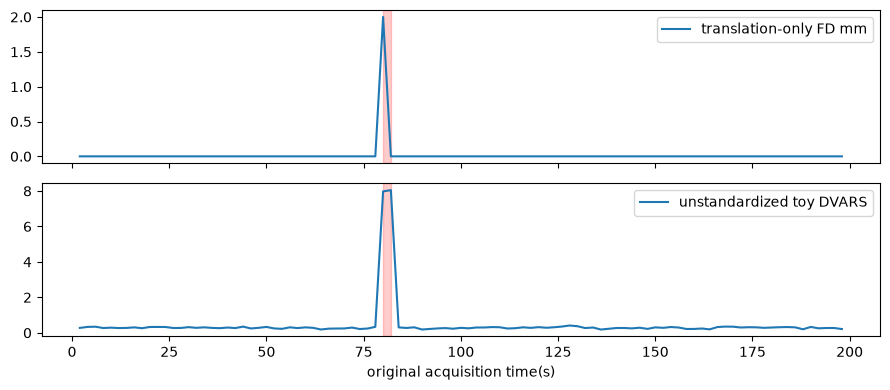

First difference undefined; censoring here is an illustrative rule only.


In [2]:
compressed_time=np.arange(keep.sum())*TR
assert not np.array_equal(compressed_time,kept_t)
fig,axes=plt.subplots(2,1,figsize=(9,4),sharex=True)
axes[0].plot(t,fd,label='translation-only FD mm'); axes[0].legend()
axes[1].plot(t,dvars,label='unstandardized toy DVARS'); axes[1].legend()
for ax in axes: ax.axvspan(80,82,alpha=.2,color='red')
axes[1].set_xlabel('original acquisition time(s)'); plt.tight_layout(); plt.show()
print('First difference undefined; censoring here is an illustrative rule only.')


## Check and explain

Frames40 and41 are excluded under the toy rule. All retained row counts match, but there is a gap larger thanTR in acquisition times. The first derivative-based measures remain undefined. A count match alone would not detect rows taken from another run.

## Deliberately wrong method

Reconstructing time as0,TR,2TR after censoring hides the gap. Filtering that compressed sequence treats nonadjacent acquisitions as neighbors. Reporting a lower mean FD after exclusion without the number of discarded frames and remaining design coverage also hides a consequence.

## Transfer to an actual dataset or tool — guided assignment

Inspect the official fMRIPrep report’s motion, carpet plot, masks and registration panels for one teaching run. Record exact inspected panels, missing panels and unresolved defects. For a mentor-selected analysis, predefine censoring and run-exclusion rules, then tabulate retained duration/events and exclusions by participant/group. The public sample is an older report, not a current benchmark. Submit observed evidence, not an AI-generated pass statement based only on a process exit code.

**Submit:** a transformation card, one labeled figure or numerical result, the failed-method diagnosis, and the upstream-practice evidence. If the external exercise has not been run, mark it **not executed** and state the missing software/data; do not convert a proposed command into a claimed result.

## Exit questions and answer key

1. Why might one spike flag two DVARS entries? **Answer:** the difference into and out of the spike is large.
2. Why retain original indices? **Answer:** they preserve timing and enable identical masking of data, confounds and design.


### Return to the research question

Reopen [PP02](../../curriculum/papers/processing.md#pp02), [PP01](../../curriculum/papers/processing.md#pp01) and your initial two-sentence prediction. In your [evidence ledger](../../curriculum/coursework/EVIDENCE_LEDGER.md):

1. Cite one output or diagnostic from this lesson and explain the transformation it demonstrates.
2. Revise one claim or question from the paper, with a figure/section locator. State what this small exercise still cannot establish about the published result.
3. Ask AI to propose a next check. Accept, revise or reject it with a scientific reason. Then explain your decision aloud without reading the AI response.

Reuse this entry in the A2 portfolio when relevant; a separate report is unnecessary.
